<a href="https://colab.research.google.com/github/lmaas37/FDD-Week-0/blob/main/03_sklearn_churn_prop_students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎯 Block 3 — scikit-learn
## The Customer Churn Game

> **The big idea:** a machine-learning model is only useful if it supports a **good decision**.

You work for a subscription company. Every month some clients **churn** (cancel). Your job is to
predict who is about to churn and decide who should receive a **retention ad** — while keeping the
**business cost** as low as possible.

**The rules of the game** 💸
- Losing a client (a churner you did *nothing* about) costs **100**.
- Sending one retention ad costs **10**.
- An ad sent to a real churner **keeps** them (you avoid the 100 loss — you only pay the ad).
- An ad sent to a *happy* client **annoys them into leaving** → you lose them (100) *and* paid the ad (10).

So spamming everyone is a terrible idea, and ignoring everyone is too. You must **target** the right
clients — which is exactly what the model is for.

**The workflow you'll build**
```
raw data → preprocessing → train/test split → fit → predict → evaluate
        → business decision → cluster the churners → targeted actions
```

This notebook runs top-to-bottom on **Google Colab**. Cells marked **🎯 TASK** are for you to
complete; visualization code is hidden behind a title (double-click to peek).


## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, silhouette_score)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

import sklearn
np.set_printoptions(precision=3, suppress=True)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
print("scikit-learn", sklearn.__version__, "ready ✅")

scikit-learn 1.6.1 ready ✅


In [2]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def pipeline_diagram():
    steps = [("🗂️", "Raw data", "clients + history"), ("🧹", "Preprocess", "scale + encode"),
             ("✂️", "Split", "train / test"), ("🌳", "Fit", "train a classifier"),
             ("🔮", "Predict", "churn probability"), ("📊", "Evaluate", "metrics + cost"),
             ("💸", "Decide", "who gets an ad"), ("🧩", "Cluster", "churn profiles")]
    grad = ["#667eea", "#6f7bf0", "#8273ec", "#9a6fe2", "#b06fd0", "#c56fbe", "#d36bb0", "#db6fa9"]
    blocks = ""
    for (ic, t, d), g in zip(steps, grad):
        blocks += (f'<div class="pl-step"><div class="pl-ic" style="background:linear-gradient(135deg,{g},{g}cc)">{ic}</div>'
                   f'<div class="pl-t">{t}</div><div class="pl-d">{d}</div></div>'
                   '<div class="pl-ar">➜</div>')
    blocks = blocks.rsplit('<div class="pl-ar">➜</div>', 1)[0]
    display(HTML(f'''
<style>
.pl{{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f6f8ff,#fbf5ff);
    border-radius:18px;padding:20px 16px;margin:8px 0;border:1px solid #ecebff}}
.pl-h{{font-size:20px;font-weight:800;color:#3b2d6b;margin:0 0 14px}}
.pl-row{{display:flex;align-items:flex-start;flex-wrap:wrap;gap:0}}
.pl-step{{flex:1 1 96px;min-width:96px;text-align:center;padding:0 2px}}
.pl-ic{{width:48px;height:48px;border-radius:50%;margin:0 auto 7px;display:flex;align-items:center;
       justify-content:center;font-size:21px;color:#fff;box-shadow:0 6px 14px rgba(102,126,234,.35)}}
.pl-t{{font-weight:700;font-size:12px;color:#2c2350}}
.pl-d{{font-size:10px;color:#8b86a6;margin-top:2px}}
.pl-ar{{display:flex;align-items:center;font-size:18px;color:#b9a9e6;flex:0 0 14px;height:48px}}
</style>
<div class="pl"><div class="pl-h">🎮 The churn-game workflow</div><div class="pl-row">{blocks}</div></div>'''))

pipeline_diagram()

## The data

The company gives us two synthetic datasets:

- **`historical_df`** — past clients with the known outcome `churned` (0/1). We learn from this.
- **`current_df`** — this month's clients, **without** a churn label. We must predict for these.

Each client has behavioural features *plus* some junk columns (an id, a name, an email, an internal
code, and a suspicious `future_information` field). Part of the job is deciding what belongs in a
model.

In [3]:
#@title ▶️ Run me (helper code) { display-mode: "form" }
def _make_clients(n, seed, with_label=True):
    rng = np.random.default_rng(seed)
    personas = ["loyal", "happy_new", "inactive", "frustrated", "new_low"]
    persona = rng.choice(personas, size=n, p=[0.34, 0.14, 0.18, 0.15, 0.19])
    usage = np.zeros(n); days = np.zeros(n); age = np.zeros(n)
    tickets = np.zeros(n, int); late = np.zeros(n, int)

    def fill(mask, u, d, a, t, l):
        k = int(mask.sum())
        if k == 0:
            return
        usage[mask] = np.clip(rng.normal(u[0], u[1], k), 0, None)
        days[mask] = np.clip(rng.normal(d[0], d[1], k), 0, 90)
        age[mask] = np.clip(rng.normal(a[0], a[1], k), 1, 60)
        tickets[mask] = rng.poisson(t, k)
        late[mask] = rng.poisson(l, k)

    # Each churn persona is extreme on ONE axis (similar otherwise) so the three form clear,
    # roughly equidistant clusters: inactive=very absent, frustrated=tickets/late, new_low=brand new.
    fill(persona == "loyal",      (42, 8),  (4, 2),   (36, 6),  0, 0.1)
    fill(persona == "happy_new",  (40, 8),  (4, 2),   (5, 2),   0, 0.2)
    fill(persona == "inactive",   (20, 4),  (55, 5),  (24, 4),  1, 0.3)   # axis: days_since_last_login ↑
    fill(persona == "frustrated", (20, 4),  (8, 3),   (24, 4),  12, 2.5)  # axis: support_tickets / late ↑
    fill(persona == "new_low",    (20, 4),  (8, 3),   (3, 1.5), 1, 0.3)   # axis: subscription_age ↓

    discount_used = (rng.random(n) < np.where(np.isin(persona, ["new_low", "inactive"]), 0.12, 0.4)).astype(int)
    plan_type = rng.choice(["basic", "standard", "premium"], size=n, p=[0.5, 0.32, 0.18])
    customer_segment = rng.choice(["consumer", "SMB", "enterprise"], size=n, p=[0.6, 0.3, 0.1])

    churn_base = {"loyal": 0.05, "happy_new": 0.10, "inactive": 0.74,
                  "frustrated": 0.60, "new_low": 0.50}
    base = np.array([churn_base[p] for p in persona])
    prob = np.clip(base + 0.10 * (late >= 2) + 0.08 * (days > 40)
                   - 0.07 * discount_used - 0.05 * (age > 24), 0.02, 0.97)
    churned = (rng.random(n) < prob).astype(int)

    first = rng.choice(["Alex", "Sam", "Jo", "Lee", "Max", "Kim", "Ada", "Ravi", "Mia", "Noah"], n)
    df = pd.DataFrame({
        "client_id": [f"C{200000 + seed * 100000 + i}" for i in range(n)],
        "name": [f"{f} {chr(65 + (i % 26))}." for i, f in enumerate(first)],
        "email": [f"{f.lower()}{i}@example.com" for i, f in enumerate(first)],
        "monthly_usage_hours": usage.round(1),
        "days_since_last_login": days.round(0).astype(int),
        "subscription_age_months": age.round(0).astype(int),
        "support_tickets": tickets,
        "late_payments": late,
        "plan_type": plan_type,
        "discount_used": discount_used,
        "customer_segment": customer_segment,
        "random_internal_code": rng.integers(10000, 99999, n),
    })
    if with_label:
        df["churned"] = churned
        # a LEAKING column: recorded only after the month ends (mirrors the answer)
        df["future_information"] = np.where(churned == 1, "cancel_logged", "active")
    else:
        df["future_information"] = "pending"
    return df, churned

historical_df, _ = _make_clients(2000, seed=1, with_label=True)
current_df, current_true_churn = _make_clients(1000, seed=2, with_label=False)  # labels hidden!

baseline = historical_df["churned"].mean()

print("historical_df:", historical_df.shape, "· current_df:", current_df.shape)
print("historical churn rate:", historical_df["churned"].mean().round(3))

print(f"Baseline churn rate: {baseline:.1%}")
print(f"If we ad no one, cost = {baseline * 100 * len(historical_df):.0f}")

historical_df: (2000, 14) · current_df: (1000, 13)
historical churn rate: 0.348
Baseline churn rate: 34.8%
If we ad no one, cost = 69600


In [4]:
display(historical_df.head(6))
print("\nColumns:", list(historical_df.columns))

,client_id,name,email,monthly_usage_hours,days_since_last_login,subscription_age_months,support_tickets,late_payments,plan_type,discount_used,customer_segment,random_internal_code,churned,future_information
0,C300000,Kim A.,kim0@example.com,16.4,52,25,1,0,basic,1,consumer,35517,1,cancel_logged
1,C300001,Noah B.,noah1@example.com,21.5,9,2,2,0,standard,1,consumer,61641,1,cancel_logged
2,C300002,Ada C.,ada2@example.com,34.0,2,26,0,1,basic,0,consumer,32345,0,active
3,C300003,Ravi D.,ravi3@example.com,14.9,14,3,0,0,basic,0,consumer,98877,1,cancel_logged
4,C300004,Jo E.,jo4@example.com,43.1,5,31,0,0,basic,0,consumer,12674,0,active
5,C300005,Sam F.,sam5@example.com,27.0,3,6,0,0,basic,0,SMB,62116,0,active



Columns: ['client_id', 'name', 'email', 'monthly_usage_hours', 'days_since_last_login', 'subscription_age_months', 'support_tickets', 'late_payments', 'plan_type', 'discount_used', 'customer_segment', 'random_internal_code', 'churned', 'future_information']


## Step 1 — Preprocess: choose and prepare the features

Not every column belongs in a model. Three **traps** to watch for:

- **Identifiers** — values that are essentially unique to each client (codes, names, contact details).
  They carry no general signal, so the model would simply *memorise* them.
- **Leakage** — a column whose value is only known *after* the moment you'd need the prediction. It
  effectively contains the answer: the model looks perfect in training and falls apart in real life.
- **The target** — the very thing we are trying to predict. It can never sit among the inputs.

Everything else is a real **feature**, and features come in two flavours that need *different*
preprocessing:

- **numerical** (quantities living on different scales) → **standardize** with `StandardScaler`.
- **categorical** (a handful of text labels) → **one-hot encode** with `OneHotEncoder`.

A `ColumnTransformer` then applies the right transform to the right columns in one object.

👇 **First, sort the columns yourself.** Drag each column into the box where it belongs — it turns
**green** if it's right and **red** if it's wrong. (Look back at `historical_df.head()` if unsure.)

In [5]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
import json as _json

CORRECT = {
    "client_id": "drop", "name": "drop", "email": "drop",
    "random_internal_code": "drop", "future_information": "drop",
    "churned": "target",
    "monthly_usage_hours": "num", "days_since_last_login": "num",
    "subscription_age_months": "num", "support_tickets": "num",
    "late_payments": "num", "discount_used": "num",
    "plan_type": "cat", "customer_segment": "cat",
}
BOXES = [("drop", "🗑️ Drop (id / leakage)", "#fdecea", "#f2c4bd"),
         ("num", "🔢 Numerical", "#eef3ff", "#c9d6f5"),
         ("cat", "🏷️ Categorical", "#eafaf0", "#bfe9cf"),
         ("target", "🎯 Target", "#f3eefb", "#d9c9f2")]

_cols = list(CORRECT.keys())[::-1]   # mixed-up order for the pool
chips = "".join(f'<div class="ft-chip" draggable="true" data-col="{c}">{c}</div>' for c in _cols)
boxes = "".join(
    f'<div class="ft-box" style="background:{bg};border-color:{bd}"><div class="ft-bh">{title}</div>'
    f'<div class="ft-drop" data-drop="{bid}"></div></div>'
    for bid, title, bg, bd in BOXES)

_TPL = '''
<style>
#__UID__{font-family:system-ui,Segoe UI,Roboto,sans-serif;border:1px solid #e6e8ee;border-radius:16px;padding:14px;max-width:860px}
#__UID__ .ft-pool{display:flex;flex-wrap:wrap;gap:6px;min-height:38px;padding:8px;background:#f6f7fb;border-radius:10px;margin-bottom:12px}
#__UID__ .ft-boxes{display:flex;gap:10px;flex-wrap:wrap}
#__UID__ .ft-box{flex:1 1 180px;border:1px solid #e6e8ee;border-radius:12px;padding:8px 10px}
#__UID__ .ft-bh{font-size:12px;font-weight:800;color:#2c2350;margin-bottom:6px}
#__UID__ .ft-drop{min-height:90px;display:flex;flex-wrap:wrap;gap:6px;align-content:flex-start;border:2px dashed #d7dae6;border-radius:8px;padding:6px}
#__UID__ .ft-drop.over{border-color:#764ba2;background:#faf7ff}
#__UID__ .ft-chip{cursor:grab;user-select:none;font-size:12px;background:#fff;border:1px solid #d7dae6;border-radius:8px;padding:4px 9px}
#__UID__ .ft-chip.ok{background:#eafaf0;border-color:#39b36a;color:#1f7a45;font-weight:600}
#__UID__ .ft-chip.bad{background:#fdecea;border-color:#e0796d;color:#b5392a;font-weight:600}
#__UID__ .ft-msg{margin-top:12px;font-size:13px;font-weight:700;color:#3b2d6b}
</style>
<div id="__UID__">
  <div class="ft-pool ft-drop" data-drop="pool">__CHIPS__</div>
  <div class="ft-boxes">__BOXES__</div>
  <div class="ft-msg"></div>
</div>
<script>
(function(){
  const CORRECT = __DATA__, TOTAL = Object.keys(CORRECT).length;
  const root = document.getElementById("__UID__");
  const msg = root.querySelector(".ft-msg");
  let dragged = null;
  root.querySelectorAll(".ft-chip").forEach(function(ch){
    ch.addEventListener("dragstart", function(){ dragged = ch; });
  });
  root.querySelectorAll(".ft-drop").forEach(function(zone){
    zone.addEventListener("dragover", function(e){ e.preventDefault(); zone.classList.add("over"); });
    zone.addEventListener("dragleave", function(){ zone.classList.remove("over"); });
    zone.addEventListener("drop", function(e){
      e.preventDefault(); zone.classList.remove("over");
      if(!dragged) return;
      zone.appendChild(dragged);
      const box = zone.dataset.drop, col = dragged.dataset.col;
      dragged.className = "ft-chip" + (box === "pool" ? "" : (CORRECT[col] === box ? " ok" : " bad"));
      dragged = null; update();
    });
  });
  function update(){
    let ok = 0;
    root.querySelectorAll(".ft-chip.ok").forEach(function(){ ok++; });
    msg.textContent = ok === TOTAL ? ("🎉 All " + TOTAL + " columns sorted correctly!")
                                   : (ok + " / " + TOTAL + " correctly placed");
  }
  update();
})();
</script>
'''
_uid = "ft_sorter"
display(HTML(_TPL.replace("__UID__", _uid).replace("__CHIPS__", chips)
             .replace("__BOXES__", boxes).replace("__DATA__", _json.dumps(CORRECT))))

In [ ]:
#@title 📊 Churn Signal Explorer (double-click to view the code) { display-mode: "form" }
_TEMPLATE = r'''
<style>
#__UID__{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:#f6f7fb;border:1px solid #e6e8ee;border-radius:16px;padding:18px;max-width:850px}
#__UID__ .card{background:white;border:1px solid #d7dae6;border-radius:12px;padding:14px;margin-bottom:12px}
#__UID__ .card-title{font-size:12px;font-weight:800;color:#2c2350;margin-bottom:8px;text-transform:uppercase;letter-spacing:.5px}
#__UID__ .stats{display:flex;gap:12px;flex-wrap:wrap}
#__UID__ .stat-box{flex:1;min-width:220px;background:white;border:1px solid #d7dae6;border-radius:12px;padding:14px}
#__UID__ .bar-bg{width:100%;height:18px;background:#edf0f7;border-radius:999px;overflow:hidden}
#__UID__ .bar-fill{height:100%;width:0%;background:linear-gradient(90deg,#6c63ff,#8f7cff);transition:width .35s ease}
#__UID__ table{width:100%;border-collapse:collapse}
#__UID__ th{text-align:left;padding:8px;border-bottom:1px solid #eee}
#__UID__ td{padding:8px}
#__UID__ .feature-name{font-size:24px;font-weight:700;color:#2c2350}
#__UID__ select.feat{margin-top:10px;font-size:16px;font-weight:600;color:#2c2350;padding:9px 38px 9px 14px;border:1px solid #d7dae6;border-radius:10px;background:#fff url("data:image/svg+xml;utf8,<svg xmlns='http://www.w3.org/2000/svg' width='14' height='14' viewBox='0 0 24 24' fill='none' stroke='%236c63ff' stroke-width='3'><path d='M6 9l6 6 6-6'/></svg>") no-repeat right 12px center;-webkit-appearance:none;-moz-appearance:none;appearance:none;cursor:pointer;outline:none}
#__UID__ select.feat:focus{border-color:#6c63ff;box-shadow:0 0 0 3px rgba(108,99,255,.18)}
</style>

<div id="__UID__">

    <div class="card">
        <div class="card-title">Churn Signal Explorer</div>
        <div class="feature-name">📊 <span class="js-feat"></span></div>
        <div>Pick a feature to compare customers who churned versus customers who stayed.</div>
        <select class="feat">__OPTIONS__</select>
    </div>

    <div class="card">
        <div class="card-title">Correlation with Churn</div>
        <div style="font-size:24px;font-weight:700;" class="js-corr"></div>
        <br>
        <div class="bar-bg"><div class="bar-fill"></div></div>
    </div>

    <div class="card">
        <div class="card-title">Model Signal Assessment</div>
        <div style="font-size:18px;font-weight:600;" class="js-verdict"></div>
    </div>

    <div class="stats">
        <div class="stat-box">
            <div class="card-title">⚠️ Churned Customers</div>
            <table>
                <tr><td><b>Mean</b></td><td class="js-cMean"></td></tr>
                <tr><td><b>Median</b></td><td class="js-cMed"></td></tr>
                <tr><td><b>Count</b></td><td class="js-cN"></td></tr>
            </table>
        </div>
        <div class="stat-box">
            <div class="card-title">✅ Customers Who Stayed</div>
            <table>
                <tr><td><b>Mean</b></td><td class="js-sMean"></td></tr>
                <tr><td><b>Median</b></td><td class="js-sMed"></td></tr>
                <tr><td><b>Count</b></td><td class="js-sN"></td></tr>
            </table>
        </div>
    </div>

    <div class="card">
        <div class="card-title">Interpretation</div>
        Customers who churned had an average <b class="js-feat2"></b> of
        <b class="js-cMean2"></b>, compared with
        <b class="js-sMean2"></b> for customers who stayed.
        <span class="js-interp"></span>
    </div>

</div>

<script>
(function() {
    var root = document.getElementById("__UID__");
    var data = __DATA__;
    function set(cls, val) {
        root.querySelectorAll("." + cls).forEach(function(el) { el.textContent = val; });
    }
    function render(f) {
        var d = data[f];
        set("js-feat", f); set("js-feat2", f);
        set("js-corr", d.corr.toFixed(2));
        root.querySelector(".bar-fill").style.width = d.bar + "%";
        set("js-verdict", d.verdict);
        set("js-cMean", d.cMean.toFixed(1)); set("js-cMean2", d.cMean.toFixed(1));
        set("js-cMed", d.cMed.toFixed(1));
        set("js-cN", d.cN);
        set("js-sMean", d.sMean.toFixed(1)); set("js-sMean2", d.sMean.toFixed(1));
        set("js-sMed", d.sMed.toFixed(1));
        set("js-sN", d.sN);
        set("js-interp", d.interp);
    }
    var sel = root.querySelector("select.feat");
    sel.value = "__DEFAULT__";
    sel.addEventListener("change", function() { render(this.value); });
    render(sel.value);
})();
</script>
'''

# 🎯 Churn Signal Explorer — a styled dropdown, all inside the HTML (no extra libraries)
import json, uuid
from IPython.display import display, HTML

# Only numeric columns can be correlated with churn, so the menu is built from those.
# (categorical / id columns like plan_type or email are skipped to avoid errors)
numeric_features = [c for c in historical_df.select_dtypes("number").columns if c != "churned"]

# Pre-compute the stats for every feature once, so the dropdown switches instantly in the browser.
stats = {}
for feat in numeric_features:
    churned = historical_df[historical_df["churned"] == 1][feat]
    stayed = historical_df[historical_df["churned"] == 0][feat]
    corr = historical_df[[feat, "churned"]].corr().iloc[0, 1]
    strength = abs(corr)

    if strength >= 0.50:
        verdict = "Strong predictor of churn"
    elif strength >= 0.30:
        verdict = "Useful predictor of churn"
    elif strength >= 0.10:
        verdict = "Weak predictor of churn"
    else:
        verdict = "Little predictive value"

    stats[feat] = {
        "corr": float(corr),
        "bar": float(min(strength * 100 * 2, 100)),
        "verdict": verdict,
        "cMean": float(churned.mean()), "cMed": float(churned.median()), "cN": int(len(churned)),
        "sMean": float(stayed.mean()), "sMed": float(stayed.median()), "sN": int(len(stayed)),
        "interp": ("This appears to be a meaningful signal for predicting churn."
                   if strength >= 0.30 else
                   "This feature may provide only limited predictive power."),
    }

default = "monthly_usage_hours" if "monthly_usage_hours" in stats else numeric_features[0]
options = "".join(f'<option value="{f}">{f}</option>' for f in numeric_features)
uid = "churn-explorer-" + uuid.uuid4().hex[:8]

html = (
    _TEMPLATE
    .replace("__UID__", uid)
    .replace("__OPTIONS__", options)
    .replace("__DATA__", json.dumps(stats))
    .replace("__DEFAULT__", default)
)
display(HTML(html))


Mean,
Median,
Count,
Mean,
Median,
Count,


In [6]:
target = "churned"               # 🎯 the column we want to predict
drop_cols = ['client_id', 'name', 'email', 'random_internal_code','future_information']            # 🎯 identifiers + leakage to throw away (NOT the target)
numerical_features = ['monthly_usage_hours', 'days_since_last_login', 'subscription_age_months', 'support_tickets', 'late_payments', 'discount_used']   # 🎯 the numeric feature columns
categorical_features = ['plan_type', 'customer_segment'] # 🎯 the categorical feature columns

# Test
# X = the features we keep, y = the target
X = historical_df[numerical_features + categorical_features].copy()
y = historical_df[target].copy()

print("kept features:", list(X.columns))
print("target:", target, "· churn rate:", round(y.mean(), 3))

kept features: ['monthly_usage_hours', 'days_since_last_login', 'subscription_age_months', 'support_tickets', 'late_payments', 'discount_used', 'plan_type', 'customer_segment']
target: churned · churn rate: 0.348


**Test** ✅

In [ ]:
assert target == "churned", "Hint: we predict the 'churned' column."
assert "churned" not in X.columns, "Hint: the target must NOT be among the features."
assert "future_information" not in X.columns, "Hint: future_information leaks the answer — drop it."
assert "client_id" not in X.columns, "Hint: identifiers don't belong in a model."
print("Step 1 passed ✅  ", X.shape[1], "raw feature columns")

Step 1 passed ✅   8 raw feature columns


## Step 1½ — Turn columns into numbers (scaling & encoding)

A model only understands **numbers**, so before training we transform our two kinds of columns.

**Numerical features** live on very different scales (usage hours vs. a count of tickets). We
**standardize** them — subtract the mean and divide by the standard deviation — so each feature has
mean 0 and spread 1 and none dominates just by its magnitude. (Same spirit as the normalization from
Block 1; scikit-learn calls it `StandardScaler`, and the pattern is `fit` then `transform`.)

In [ ]:
scaler_demo = StandardScaler()
scaled_numeric = scaler_demo.fit_transform(X[numerical_features])
print("means after scaling:", scaled_numeric.mean(axis=0).round(2))
print("stds  after scaling:", scaled_numeric.std(axis=0).round(2))

means after scaling: [ 0. -0. -0.  0.  0. -0.]
stds  after scaling: [1. 1. 1. 1. 1. 1.]


**Visualization** — the same features before and after standardization. On the left the scales
are wildly different (days and usage dwarf the ticket/payment counts); on the right everything is
centered on 0 with a comparable spread, so no single feature can dominate by sheer magnitude.

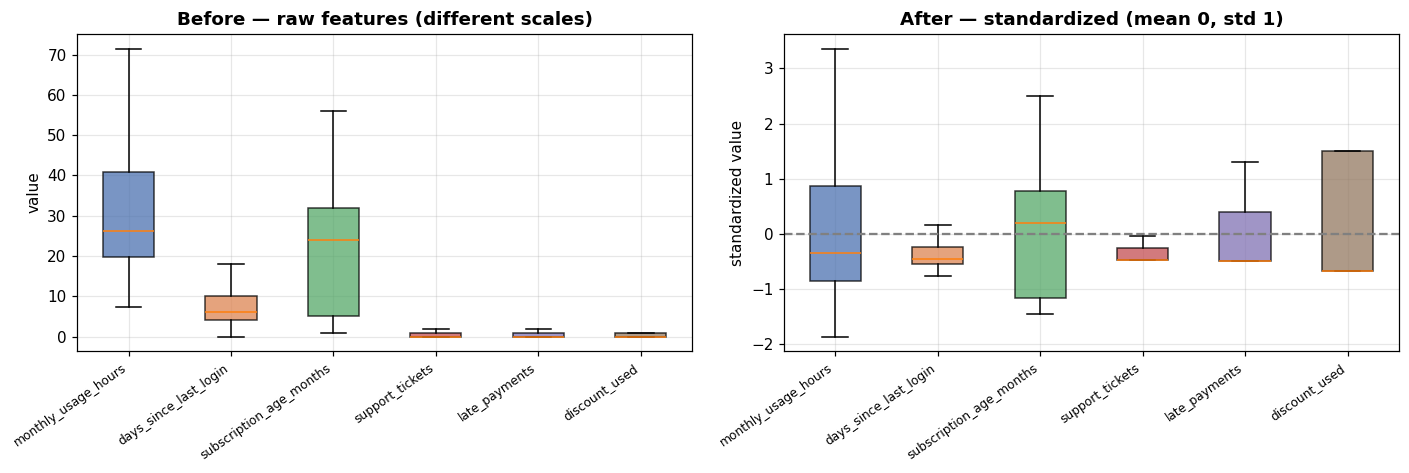

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
raw = X[numerical_features].to_numpy()
palette = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3", "#937860"]

fig, (axr, axs) = plt.subplots(1, 2, figsize=(13, 4.4))
for ax, data, title in [(axr, raw, "Before — raw features (different scales)"),
                        (axs, scaled_numeric, "After — standardized (mean 0, std 1)")]:
    bp = ax.boxplot([data[:, j] for j in range(data.shape[1])], patch_artist=True, showfliers=False)
    for patch, c in zip(bp["boxes"], palette):
        patch.set_facecolor(c); patch.set_alpha(0.75)
    ax.set_xticks(range(1, len(numerical_features) + 1))
    ax.set_xticklabels(numerical_features, rotation=35, ha="right", fontsize=8)
    ax.set_title(title, fontweight="bold")
axs.axhline(0, ls="--", color="gray")
axr.set_ylabel("value"); axs.set_ylabel("standardized value")
plt.tight_layout(); plt.show()

**Categorical features** are text labels, e.g. `plan_type ∈ {basic, standard, premium}`. We
can't feed text to a model — and we *shouldn't* just map `basic→0, standard→1, premium→2`, because
that invents a fake ordering (is `premium` really "3 × a basic"?).

The fix is **one-hot encoding**: replace one categorical column with several 0/1 columns, one per
category. A `basic` client becomes `[1, 0, 0]`, a `premium` client `[0, 0, 1]`:

| plan_type | basic | standard | premium |
|---|---|---|---|
| standard | 0 | 1 | 0 |
| premium | 0 | 0 | 1 |
| basic | 1 | 0 | 0 |

### 👉 Your task: implement one-hot encoding

Write `one_hot(values, categories)` returning a 2-D array with one **0/1 column per category** and
one row per value.

In [ ]:
def one_hot(values, categories):
    '''Return a 2-D array: one 0/1 column per category, one row per value.'''
    # 🎯 YOUR CODE HERE
    #    Think of it as a grid: one row per value, one column per category.
    #    1. Start with a grid of all zeros, size (number of values, number of categories).
    #    2. Go through the values one at a time, keeping track of the row number.
    #    3. For each value, find which column it belongs to (its position in 'categories'),
    #       and flip that one cell from 0 to 1.
    #    4. Return the finished grid.
    result = np.zeros((len(values), len(categories)), dtype=int)
    for i, value in enumerate(values):
        col_idx = categories.index(value)
        result[i, col_idx] = 1
    return result

plan_categories = sorted(X["plan_type"].unique())
print("categories:", plan_categories)
print(one_hot(X["plan_type"].to_numpy()[:5], plan_categories))

categories: ['basic', 'premium', 'standard']
[[1 0 0]
 [0 0 1]
 [1 0 0]
 [1 0 0]
 [1 0 0]]


In [ ]:
customer_categories = sorted(X["customer_segment"].unique())
print("categories:", customer_categories)
print(one_hot(X["customer_segment"].to_numpy()[:5], customer_categories))

categories: ['SMB', 'consumer', 'enterprise']
[[0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]
 [0 1 0]]


**Test** ✅

In [ ]:
_oh = one_hot(X["plan_type"].to_numpy(), plan_categories)
assert _oh.shape == (len(X), len(plan_categories)), "Hint: one row per value, one column per category."
assert (_oh.sum(axis=1) == 1).all(), "Hint: each row should have exactly one 1 — its category."
print("one_hot passed ✅")

one_hot passed ✅


**The scikit-learn version.** `OneHotEncoder` does exactly this — and it also *remembers* the
categories it saw during `fit`, can ignore unseen ones at predict time (`handle_unknown="ignore"`),
and can return a compact sparse matrix. Let's confirm it matches our hand-rolled version:

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
sk_oh = encoder.fit_transform(X[["plan_type"]]).astype(int)
print("sklearn categories:", list(encoder.categories_[0]))
print("matches our one_hot:",
      np.array_equal(sk_oh, one_hot(X["plan_type"].to_numpy(), list(encoder.categories_[0]))))

sklearn categories: ['basic', 'premium', 'standard']
matches our one_hot: True


**Visualization** — how each category becomes a vector. One categorical column turns into one
0/1 column **per category**, and a given client lights up exactly one of them (the green `1`).

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
_OH_STYLE = '''
<style>
.oh-wrap{font-family:system-ui,Segoe UI,Roboto,sans-serif;display:flex;gap:22px;flex-wrap:wrap}
.oh-title{font-weight:800;color:#2c2350;margin-bottom:6px;font-size:14px}
.oh-t{border-collapse:separate;border-spacing:4px}
.oh-t th{font-size:11px;color:#6b6685;font-weight:600;padding:2px 4px}
.oh-t th.oh-cat{text-align:right;color:#2c2350;font-weight:700}
.oh-t td{width:54px;height:30px;text-align:center;border-radius:7px;font-size:13px}
.oh-t td.oh-arrow{background:none;color:#b9a9e6;font-size:18px;font-weight:700;width:20px}
</style>'''

def one_hot_map_html(feature):
    cats = sorted(X[feature].unique())
    enc = OneHotEncoder(sparse_output=False)
    M = enc.fit_transform(np.array(cats).reshape(-1, 1)).astype(int)
    cols = list(enc.categories_[0])
    head = "".join(f'<th>{feature}<br>= {c}</th>' for c in cols)
    rows = ""
    for cat, vec in zip(cats, M):
        cells = "".join(
            f'<td style="background:{"#39b36a" if v else "#eef0f5"};color:{"#fff" if v else "#b8bcc8"};'
            f'font-weight:{700 if v else 400}">{v}</td>' for v in vec)
        rows += f'<tr><th class="oh-cat">{cat}</th><td class="oh-arrow">&rarr;</td>{cells}</tr>'
    return (f'<div><div class="oh-title">🏷️ {feature}</div>'
            f'<table class="oh-t"><tr><th></th><th></th>{head}</tr>{rows}</table></div>')

display(HTML(_OH_STYLE + '<div class="oh-wrap">'
            + "".join(one_hot_map_html(f) for f in categorical_features) + "</div>"))

,,plan_type= basic,plan_type= premium,plan_type= standard
basic,→,1,0,0
premium,→,0,1,0
standard,→,0,0,1
,,customer_segment= SMB,customer_segment= consumer,customer_segment= enterprise
SMB,→,1,0,0
consumer,→,0,1,0
enterprise,→,0,0,1


### Combining both: `ColumnTransformer`

Numeric columns need `StandardScaler`, categorical columns need `OneHotEncoder`. A
**`ColumnTransformer`** applies each transform to its own columns and stitches the results back into
a single numeric matrix — exactly what we need for mixed data like ours.

**The syntax.** You hand `ColumnTransformer` a *list of steps*, where each step is a tuple of three things:

```python
("a_name", SomeTransformer(), list_of_columns)
```

- **name** — any label you choose (e.g. `"num"`); it just tags that step so you can find it later.
- **transformer** — an *instance* of the transformer to apply (note the `()` — you build it here, you do **not** call `.fit` yourself).
- **columns** — the list of column names this transformer should act on.

So a `ColumnTransformer([...])` holds one such tuple per group of columns. Any column you do **not**
list is dropped by default. Once built, you use it like any other transformer: `.fit_transform(X)`
runs every step on its own columns and glues the outputs side by side into one matrix.

> 💡 For `OneHotEncoder`, pass `handle_unknown="ignore"` so a category it never saw during training
> becomes all-zeros instead of crashing at prediction time.


In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
num_chips = "".join(f'<div class="ct-chip ct-num">{c}</div>' for c in numerical_features)
cat_chips = "".join(f'<div class="ct-chip ct-cat">{c}</div>' for c in categorical_features)

_CT = '''
<style>
.ct{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f7f8ff,#fdf6ff);
    border:1px solid #ecebff;border-radius:16px;padding:16px;margin:6px 0}
.ct-flow{display:flex;align-items:center;gap:10px;flex-wrap:wrap;justify-content:center}
.ct-col{display:flex;flex-direction:column;gap:5px;max-width:230px}
.ct-h{font-size:12px;font-weight:800;color:#3b2d6b;margin-bottom:3px}
.ct-chip{font-size:11px;border-radius:7px;padding:4px 8px;border:1px solid}
.ct-num{background:#eef3ff;border-color:#c9d6f5;color:#2f4a8a}
.ct-cat{background:#eafaf0;border-color:#bfe9cf;color:#1f7a45}
.ct-ar{font-size:22px;color:#b9a9e6;font-weight:800}
.ct-mid{display:flex;flex-direction:column;gap:10px}
.ct-branch{border-radius:12px;padding:10px 12px;font-size:12px;text-align:center;line-height:1.5}
.ct-branch span{font-size:10px;color:#777}
.ct-branch.numb{background:#eef3ff;border:1px solid #c9d6f5}
.ct-branch.catb{background:#eafaf0;border:1px solid #bfe9cf}
.ct-out{background:#fff;border:1px solid #e6e8ee;border-radius:12px;padding:12px;text-align:center}
.ct-note{font-size:11px;color:#555;line-height:1.6}
</style>
<div class="ct"><div class="ct-flow">
  <div class="ct-col"><div class="ct-h">Input columns (mixed)</div>__NUM____CAT__</div>
  <div class="ct-ar">&rarr;</div>
  <div class="ct-mid">
    <div class="ct-branch numb">🔢 numeric &rarr; <b>StandardScaler</b><br><span>centered &amp; scaled</span></div>
    <div class="ct-branch catb">🏷️ categorical &rarr; <b>OneHotEncoder</b><br><span>0/1 columns</span></div>
  </div>
  <div class="ct-ar">&rarr;</div>
  <div class="ct-out"><div class="ct-h">One numeric matrix</div>
    <div class="ct-note">scaled columns + one-hot columns<br>glued side by side<br><b>ready for the model</b></div></div>
</div></div>
'''
display(HTML(_CT.replace("__NUM__", num_chips).replace("__CAT__", cat_chips)))

In [ ]:
# 🎯 TASK — build a ColumnTransformer that:
#    • scales the numeric columns with StandardScaler
#    • one-hot encodes the categorical columns with OneHotEncoder
#
#    Reread the syntax above: ColumnTransformer takes a LIST of (name, transformer, columns)
#    tuples — one tuple per group. Fill in the two blanks below, then uncomment.
#
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numerical_features),    # scale the numeric columns
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),  # one-hot the categorical columns
])
#    ↑ which transformer goes in each "...transformer..." slot? and remember the
#      handle_unknown="ignore" argument belongs on the one-hot encoder.
# preprocessor = None  # 🎯 YOUR CODE HERE

peek = preprocessor.fit_transform(X)   # peek at the result (the pipeline will refit this on the training split later)
print("transformed shape:", peek.shape, "(rows, expanded columns)")

transformed shape: (2000, 12) (rows, expanded columns)


In [ ]:
print('Transformed column names:', preprocessor.get_feature_names_out())

Transformed column names: ['num__monthly_usage_hours' 'num__days_since_last_login'
 'num__subscription_age_months' 'num__support_tickets'
 'num__late_payments' 'num__discount_used' 'cat__plan_type_basic'
 'cat__plan_type_premium' 'cat__plan_type_standard'
 'cat__customer_segment_SMB' 'cat__customer_segment_consumer'
 'cat__customer_segment_enterprise']


**Test** ✅

In [ ]:
assert preprocessor is not None, "Hint: build the ColumnTransformer."
assert peek.shape[0] == len(X), "Hint: same number of rows as X."
assert peek.shape[1] > len(numerical_features), "Hint: one-hot encoding adds extra columns."
print("Step 1½ passed ✅  feature matrix is", peek.shape[1], "columns wide after encoding")

Step 1½ passed ✅  feature matrix is 12 columns wide after encoding


## Step 2 — Train / test split

We must judge the model on data it has **never seen** — that simulates next month's clients. So we
hold out a **test set**. Training accuracy alone is misleading: a model can *memorise* the training
data (overfit) and still fail on new clients.

`train_test_split` shuffles and splits. We pass `stratify=y` so both halves keep the same churn
rate, and a fixed `random_state` so results are reproducible.

In [ ]:
# 🎯 TASK — split X, y into train (80%) and test (20%) sets.
#    Use sklearn train_test_split. A few things to get right:
#    • reserve 20% for the test set (look up the test_size argument)
#    • churn is imbalanced, so keep the class proportions equal in both splits (stratify)
#    • fix the randomness so the split is reproducible (random_state)
#    Remember it returns FOUR arrays, in the order X_train, X_test, y_train, y_test.
X_train, X_test, y_train, y_test = None, None, None, None   # 🎯 fill this in

print("train:", X_train.shape, "· test:", X_test.shape)
print("churn rate  train:", round(y_train.mean(), 3), "· test:", round(y_test.mean(), 3))

AttributeError: 'NoneType' object has no attribute 'shape'

**Test** ✅

In [ ]:
assert X_train.shape[0] == y_train.shape[0], "Hint: X and y must have the same number of rows."
assert X_train.shape[0] > X_test.shape[0], "Hint: the training set should be the larger split."
assert abs(y_train.mean() - y_test.mean()) < 0.05, "Hint: use stratify=y so both sets share the churn rate."
print("Step 2 passed ✅")

Step 2 passed ✅


## Step 3 — Train a classifier (inside a Pipeline)

Right now preprocessing (`preprocessor`) and the model are two separate things. A scikit-learn
**`Pipeline`** chains them into **one object**: data enters at the top, flows through each step in
order, and the **last step is the model**.

```python
Pipeline([
    ("preprocessor", preprocessor),           # step 1: scale + one-hot encode
    ("model", DecisionTreeClassifier(...)),   # step 2: the classifier
])
```

Why use a pipeline instead of calling the steps by hand?
- **No leakage.** `pipeline.fit(X_train, y_train)` fits the scaler/encoder **and** the model on the
  *training* data only — the test set never sneaks into the scaling.
- **No mismatch.** `pipeline.predict(X_new)` automatically replays the *exact same* fitted transforms
  before the model sees the data, so you can never forget a step or apply it differently.
- **One object** to pass around, evaluate, and (next step) grid-search.

We start with a **DecisionTreeClassifier** — simple, fast, and easy to interpret. The methods you
call on the whole pipeline:
- `fit(X_train, y_train)` — learn every step from the training data.
- `predict(X)` — output a 0/1 label.
- `predict_proba(X)[:, 1]` — the **probability of churn** (column 1), which we'll use to tune the
  business decision later.

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
display(HTML('''
<style>
.pp{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f7f8ff,#fdf6ff);
    border:1px solid #ecebff;border-radius:16px;padding:16px;margin:6px 0}
.pp-flow{display:flex;align-items:center;justify-content:center;gap:10px;flex-wrap:wrap}
.pp-data,.pp-out{font-size:12px;font-weight:700;color:#3b2d6b;text-align:center}
.pp-data span,.pp-out span{font-weight:400;color:#8b86a6;font-size:10px}
.pp-step{border-radius:12px;padding:12px 14px;text-align:center;font-size:12px;font-weight:700;color:#2c2350}
.pp-step span{display:block;font-weight:400;color:#777;font-size:10px;margin-top:2px}
.pp-s1{background:#eef3ff;border:1px solid #c9d6f5}
.pp-s2{background:#f3eefb;border:1px solid #d9c9f2}
.pp-ar{font-size:20px;color:#b9a9e6;font-weight:800}
.pp-modes{display:flex;gap:10px;flex-wrap:wrap;margin-top:12px}
.pp-mode{flex:1 1 260px;border-radius:10px;padding:9px 12px;font-size:12px;line-height:1.4}
.pp-fit{background:#eafaf0;border:1px solid #bfe9cf}
.pp-pred{background:#eef3ff;border:1px solid #c9d6f5}
</style>
<div class="pp">
  <div class="pp-flow">
    <div class="pp-data">X<br><span>raw clients</span></div>
    <div class="pp-ar">&rarr;</div>
    <div class="pp-step pp-s1">① preprocessor<span>StandardScaler + OneHotEncoder</span></div>
    <div class="pp-ar">&rarr;</div>
    <div class="pp-step pp-s2">② model<span>DecisionTreeClassifier</span></div>
    <div class="pp-ar">&rarr;</div>
    <div class="pp-out">churn<br><span>label / probability</span></div>
  </div>
  <div class="pp-modes">
    <div class="pp-mode pp-fit">🟢 <b>.fit(X_train, y_train)</b><br>learns <i>both</i> steps on the training data</div>
    <div class="pp-mode pp-pred">🔵 <b>.predict(X) / .predict_proba(X)</b><br>replays the <i>same</i> fitted steps on new data</div>
  </div>
</div>'''))

In [ ]:
# 🎯 TASK — build a Pipeline(preprocessor → DecisionTreeClassifier), fit it, and predict.
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=5, random_state=0)),
])

# 🎯 fit the pipeline on the TRAINING split (the whole pipeline trains in one call)

# 🎯 then, on the TEST split, produce:
#    predictions   — the hard 0/1 label the model assigns to each row
#    probabilities — the probability of churn (class 1). predict_proba returns one
#                    column per class, so you only want the class-1 column.
predictions   = None   # 🎯 YOUR CODE HERE
probabilities = None   # 🎯 YOUR CODE HERE

print("first 8 predicted labels :", predictions[:8])
print("first 8 churn probas     :", probabilities[:8].round(2))

first 8 predicted labels : [0 0 0 0 1 0 0 0]
first 8 churn probas     : [0.45 0.04 0.01 0.01 0.72 0.45 0.08 0.01]


**Test** ✅

In [ ]:
assert predictions.shape[0] == y_test.shape[0], "Hint: predict on X_test."
assert probabilities.min() >= 0 and probabilities.max() <= 1, "Hint: use predict_proba(...)[:, 1] for probabilities."
print("Step 3 passed ✅")

Step 3 passed ✅


**Visualization** — the decision tree the model learned (top levels) and which features it relies on.

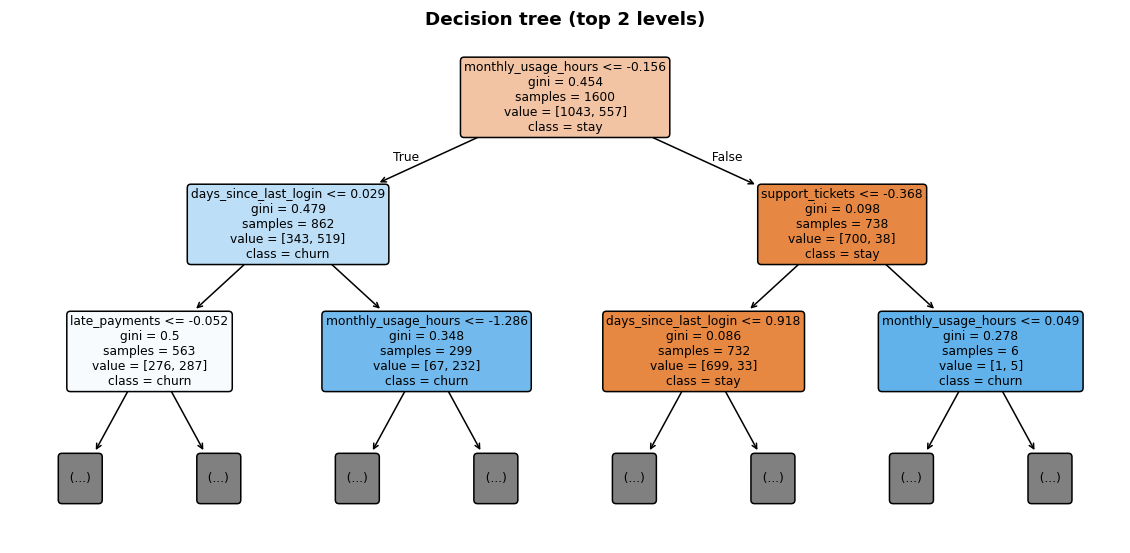

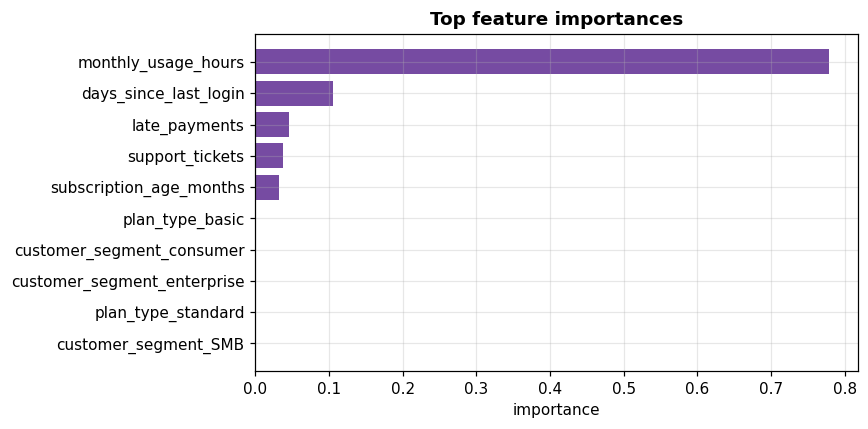

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
fig, ax = plt.subplots(figsize=(13, 6))
feat_names = (numerical_features +
              list(tree_model.named_steps["preprocessor"]
                   .named_transformers_["cat"].get_feature_names_out(categorical_features)))
plot_tree(tree_model.named_steps["model"], max_depth=2, feature_names=feat_names,
          class_names=["stay", "churn"], filled=True, rounded=True, fontsize=8, ax=ax)
ax.set_title("Decision tree (top 2 levels)", fontweight="bold")
plt.show()

importances = tree_model.named_steps["model"].feature_importances_
order = np.argsort(importances)[::-1][:10]
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh([feat_names[i] for i in order][::-1], importances[order][::-1], color="#764ba2")
ax.set_title("Top feature importances", fontweight="bold"); ax.set_xlabel("importance")
plt.tight_layout(); plt.show()

# step 3.B - Build a second classifier for comparison

A single classifier tells you something, but you don't know if it's *good enough* until you compare it to something else. By building a second, fundamentally different classifier, you learn to:

- Spot which model type suits your data better
- Avoid falling in love with your first result
- Build the skill of **model selection** — a real-world necessity

### 🎯 TASK Create a second pipeline

We'll use a **LogisticRegression** classifier. It works very differently from a DecisionTree:

- DecisionTree = rules / splits / if-then logic
- LogisticRegression = linear combination + sigmoid curve

```python
from sklearn.linear_model import LogisticRegression

pipeline_lr = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=42))
])

In [ ]:

# 🎯 TASK — build a Pipeline(preprocessor → LogisticRegression), fit it, and predict.
logistic_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=1000, random_state=0)),
])

# 🎯 fit the pipeline on the TRAINING split (same recipe as the tree above)

# 🎯 then, on the TEST split, produce the labels and the churn (class-1) probabilities
predictions_lr   = None   # 🎯 YOUR CODE HERE
probabilities_lr = None   # 🎯 YOUR CODE HERE

print("first 8 predicted labels :", predictions_lr[:8])
print("first 8 churn probas     :", probabilities_lr[:8].round(2))

first 8 predicted labels : [0 0 0 0 1 0 0 0]
first 8 churn probas     : [0.45 0.03 0.08 0.03 0.77 0.41 0.16 0.04]


In [ ]:
assert predictions_lr.shape[0] == y_test.shape[0], "Hint: predict on X_test."
assert probabilities_lr.min() >= 0 and probabilities.max() <= 1, "Hint: use predict_proba(...)[:, 1] for probabilities."
print("Step 3 passed ✅")

Step 3 passed ✅


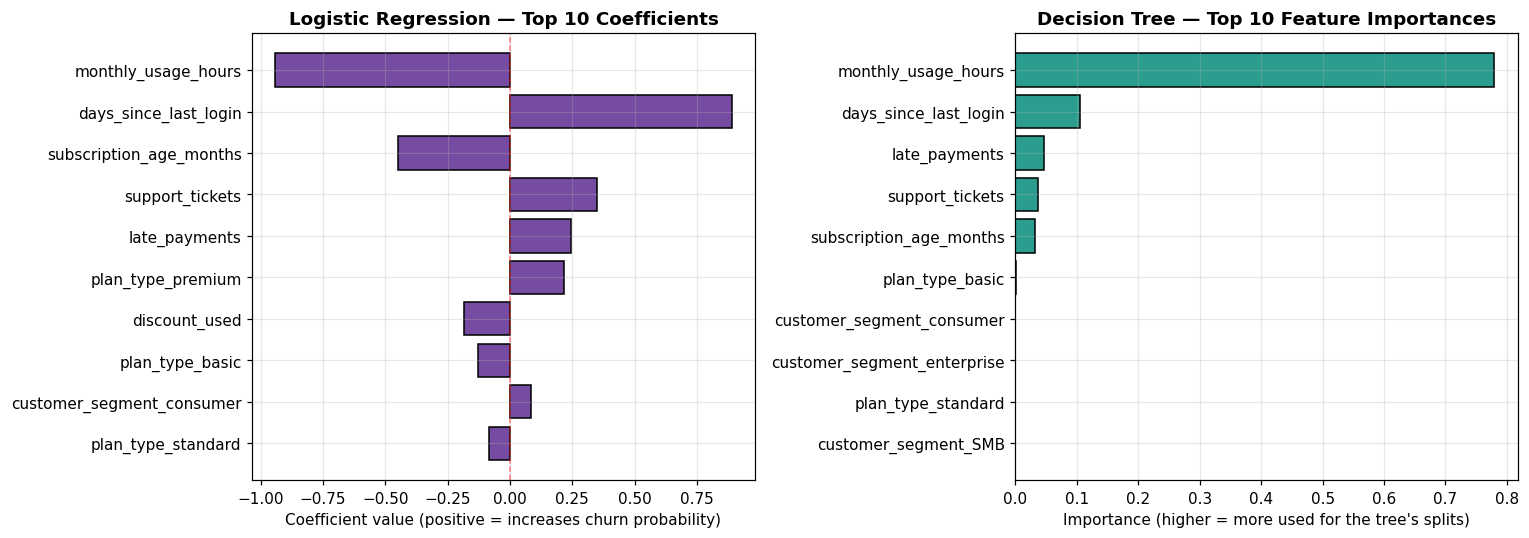

In [ ]:
#@title 📊 Logistic Regression vs Tree — coefficients & feature importance { display-mode: "form" }

feat_names = (numerical_features +
              list(logistic_model.named_steps["preprocessor"]
                   .named_transformers_["cat"].get_feature_names_out(categorical_features)))

# --- Logistic Regression: signed coefficients (sign = direction, magnitude = strength) ---
coefficients = logistic_model.named_steps["model"].coef_[0]
order_lr = np.argsort(np.abs(coefficients))[::-1][:10]

# --- Decision Tree: feature importances (the tree-based model trained earlier in Step 3) ---
importances = tree_model.named_steps["model"].feature_importances_
order_tree = np.argsort(importances)[::-1][:10]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: logistic regression coefficients
axes[0].barh([feat_names[i] for i in order_lr][::-1], coefficients[order_lr][::-1],
             color="#764ba2", edgecolor="black")
axes[0].set_title("Logistic Regression — Top 10 Coefficients", fontweight="bold")
axes[0].set_xlabel("Coefficient value (positive = increases churn probability)")
axes[0].axvline(x=0, color="red", linestyle="--", alpha=0.5, linewidth=1)

# Right: decision tree feature importances (same idea as the plot in Step 3)
axes[1].barh([feat_names[i] for i in order_tree][::-1], importances[order_tree][::-1],
             color="#2a9d8f", edgecolor="black")
axes[1].set_title("Decision Tree — Top 10 Feature Importances", fontweight="bold")
axes[1].set_xlabel("Importance (higher = more used for the tree's splits)")

plt.tight_layout()
plt.show()


## Step 4 — Evaluate: metrics first, then **business cost**

"Accuracy" is only *one* way to be right. Every metric reads the same **confusion matrix** — the 2×2
table of correct vs. mistaken predictions — but from a different angle. The diagram shows what each
one measures and which cells of the matrix it uses.

Here churn is the **positive** class, so **recall** (catching real churners) matters a lot — a
missed churner is an expensive lost client. We'll make that trade-off concrete with the business cost
just below.

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
def _mini(hi):
    names = ["TP", "FN", "FP", "TN"]
    return '<div class="mm">' + "".join(
        f'<div class="mm-c{" on" if k in hi else ""}">{names[k]}</div>' for k in range(4)) + "</div>"

cards = [
    ("Accuracy", "of <i>all</i> clients, how many did we label correctly?", "(TP + TN) / all", {0, 3}),
    ("Precision", "of those we <b>flagged as churn</b>, how many really churn?", "TP / (TP + FP)", {0, 2}),
    ("Recall", "of the <b>real churners</b>, how many did we catch?", "TP / (TP + FN)", {0, 1}),
    ("F1", "the balance (harmonic mean) of precision &amp; recall", "2·P·R / (P + R)", {0, 1, 2}),
]
cards_html = "".join(
    f'<div class="me-card"><div class="me-h">{n}</div><div class="me-d">{d}</div>'
    f'<div class="me-f">{f}</div>{_mini(hi)}</div>' for n, d, f, hi in cards)

_ME = '''
<style>
.me{font-family:system-ui,Segoe UI,Roboto,sans-serif}
.me-cm{border-collapse:separate;border-spacing:4px;margin-bottom:14px}
.me-cm th{font-size:11px;color:#6b6685;font-weight:700;padding:2px 6px}
.me-cm td{width:120px;height:54px;border-radius:10px;text-align:center;font-size:13px;font-weight:800;color:#fff;vertical-align:middle}
.me-cm td span{display:block;font-size:10px;font-weight:400;opacity:.9}
.me-good{background:#39b36a}.me-bad{background:#e0796d}
.me-cards{display:flex;gap:12px;flex-wrap:wrap}
.me-card{flex:1 1 165px;border:1px solid #e6e8ee;border-radius:12px;padding:11px 13px;background:#fff}
.me-h{font-weight:800;color:#2c2350;font-size:14px}
.me-d{font-size:11px;color:#666;margin:4px 0 6px;line-height:1.4;min-height:46px}
.me-f{font-size:12px;color:#3b2d6b;background:#f3eefb;border-radius:6px;padding:3px 6px;display:inline-block;margin-bottom:8px}
.mm{display:grid;grid-template-columns:repeat(2,1fr);gap:3px;width:84px}
.mm-c{font-size:9px;text-align:center;padding:5px 0;border-radius:5px;background:#eef0f5;color:#aab}
.mm-c.on{background:#8a4fd0;color:#fff;font-weight:700}
</style>
<div class="me">
  <table class="me-cm">
    <tr><th></th><th colspan="2">predicted</th></tr>
    <tr><th></th><th>churn</th><th>stay</th></tr>
    <tr><th>actual&nbsp;churn</th>
        <td class="me-good">TP<span>caught churner</span></td>
        <td class="me-bad">FN<span>missed churner</span></td></tr>
    <tr><th>actual&nbsp;stay</th>
        <td class="me-bad">FP<span>false alarm</span></td>
        <td class="me-good">TN<span>correct keep</span></td></tr>
  </table>
  <div class="me-cards">__CARDS__</div>
</div>'''
display(HTML(_ME.replace("__CARDS__", cards_html)))

In [ ]:
### 🎯 TASK — compute the four metrics on the test set for the decision tree classifier (y_test vs predictions).
#    Use accuracy_score, precision_score, recall_score and f1_score.
#    Each one compares the true labels against the model predictions.
acc  = None   # 🎯 accuracy_score
prec = None   # 🎯 precision_score
rec  = None   # 🎯 recall_score
f1   = None   # 🎯 f1_score

print(f"accuracy {acc:.3f} · precision {prec:.3f} · recall {rec:.3f} · f1 {f1:.3f}")

accuracy 0.805 · precision 0.740 · recall 0.676 · f1 0.707


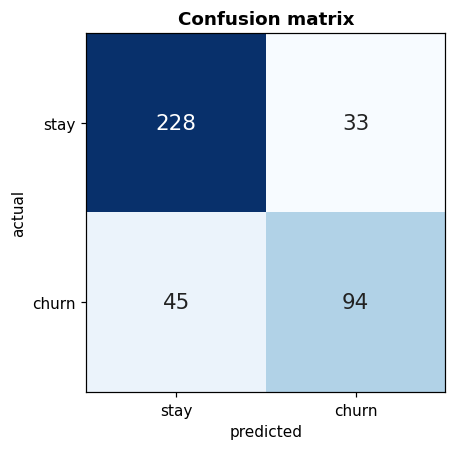

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
cm = confusion_matrix(y_test, predictions)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["stay", "churn"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["stay", "churn"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "#222")
ax.set_title("Confusion matrix", fontweight="bold"); ax.grid(False)
plt.tight_layout(); plt.show()

In [ ]:
### 🎯 TASK — compute the four metrics on the test set for the logistic regression (y_test vs the logistic predictions).
#    Same four functions as before — accuracy_score, precision_score, recall_score, f1_score.
acc_lr  = None   # 🎯 accuracy_score
prec_lr = None   # 🎯 precision_score
rec_lr  = None   # 🎯 recall_score
f1_lr   = None   # 🎯 f1_score

print(f"accuracy {acc_lr:.3f} · precision {prec_lr:.3f} · recall {rec_lr:.3f} · f1 {f1_lr:.3f}")

accuracy 0.795 · precision 0.708 · recall 0.698 · f1 0.703


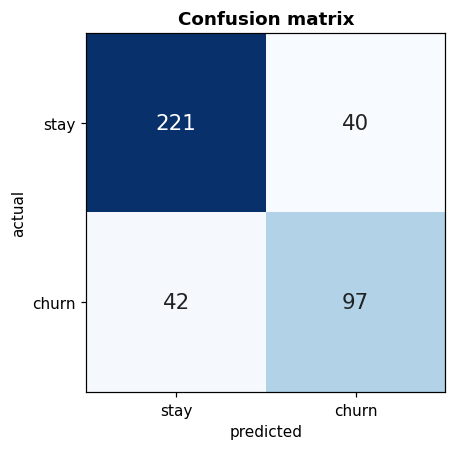

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
cm = confusion_matrix(y_test, predictions_lr)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["stay", "churn"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["stay", "churn"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "#222")
ax.set_title("Confusion matrix", fontweight="bold"); ax.grid(False)
plt.tight_layout(); plt.show()

Which model would you trust more for business decisions? Why? 🎯

## ⭐ Bonus Step 3.5 — Pipeline + Grid Search

A model has two kinds of knobs:
- **parameters** the model *learns* from data during `fit` (e.g. the splits inside a tree), and
- **hyperparameters** *you* choose **before** training (e.g. how many trees, how deep). The model
  can't learn these for you — so we **search** for good values.

**Grid search** tries **every combination** of the values you list, and scores each one with
**cross-validation** so the choice isn't down to one lucky split. Then it automatically **refits** the
best combination on all of the training data.

### What cross-validation does

Instead of trusting a single train/validation split, k-fold CV splits the training data into **k
equal folds**, then trains *k* times — each time holding out a different fold to score on — and
**averages** the k scores. A combination that does well on average is genuinely good, not lucky.

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
K = 5
rows = ""
for i in range(K):
    segs = "".join(
        f'<div class="cv-seg {"cv-val" if j == i else "cv-tr"}">{"validate" if j == i else "train"}</div>'
        for j in range(K))
    rows += (f'<div class="cv-row"><span class="cv-lab">split {i + 1}</span>'
             f'<div class="cv-bar">{segs}</div><span class="cv-sc">&rarr; score {i + 1}</span></div>')

_CV = '''
<style>
.cv{font-family:system-ui,Segoe UI,Roboto,sans-serif;background:#faf9ff;border:1px solid #ecebff;border-radius:14px;padding:14px;max-width:700px}
.cv-h{font-weight:800;color:#3b2d6b;margin-bottom:10px;font-size:14px}
.cv-row{display:flex;align-items:center;gap:8px;margin:5px 0}
.cv-lab{font-size:11px;color:#6b6685;width:46px;text-align:right}
.cv-sc{font-size:11px;color:#8b86a6;width:64px}
.cv-bar{flex:1;display:flex;gap:3px}
.cv-seg{flex:1;text-align:center;font-size:10px;padding:6px 0;border-radius:5px;color:#fff}
.cv-tr{background:#9fb3e6}
.cv-val{background:#e08a52}
.cv-foot{font-size:11px;color:#555;margin-top:10px}
</style>
<div class="cv"><div class="cv-h">🔁 k-fold cross-validation (here k = 5)</div>__ROWS__
<div class="cv-foot">Train on the blue folds, score on the held-out <b style="color:#c0710f">orange</b> fold,
rotate. The CV score = the <b>average</b> of the 5 scores. <i>(We use cv=3 in the code to keep it fast.)</i></div></div>'''
display(HTML(_CV.replace("__ROWS__", rows)))

### Grid search vs. random search

**Grid search** is exhaustive: it tries the full lattice of combinations. That's thorough but the
count **explodes** as you add parameters (3 params × 4 values each = 64 fits, then × the CV folds…).
**Random search** instead samples random combinations from the ranges — for the same budget it tries
more *distinct* values per parameter and often finds a good config faster, especially when only a few
parameters really matter.

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
gx, gy = np.meshgrid(np.linspace(16, 84, 4), np.linspace(16, 84, 4))
grid_pts = list(zip(gx.ravel(), gy.ravel()))
rng = np.random.default_rng(3)
rand_pts = list(zip(rng.uniform(8, 92, 16), rng.uniform(8, 92, 16)))

def _dots(pts, color):
    return "".join(f'<span class="gr-dot" style="left:{x:.0f}%;top:{y:.0f}%;background:{color}"></span>'
                   for x, y in pts)

_GR = '''
<style>
.gr{font-family:system-ui,Segoe UI,Roboto,sans-serif;display:flex;gap:18px;flex-wrap:wrap}
.gr-card{flex:1 1 230px}
.gr-title{font-weight:800;color:#2c2350;font-size:13px;margin-bottom:6px}
.gr-box{position:relative;height:170px;border:1px solid #e6e8ee;border-radius:12px;background:#fbfbfe}
.gr-dot{position:absolute;width:11px;height:11px;border-radius:50%;transform:translate(-50%,-50%);box-shadow:0 1px 3px rgba(0,0,0,.25)}
.gr-x{font-size:10px;color:#8b86a6;text-align:center;margin-top:4px}
.gr-foot{font-size:11px;color:#555;margin-top:8px}
</style>
<div><div class="gr">
  <div class="gr-card"><div class="gr-title">🔲 Grid search — every combination</div>
    <div class="gr-box">__GRID__</div><div class="gr-x">hyperparameter A &rarr; (B on the vertical axis)</div></div>
  <div class="gr-card"><div class="gr-title">🎲 Random search — random samples</div>
    <div class="gr-box">__RAND__</div><div class="gr-x">hyperparameter A &rarr; (B on the vertical axis)</div></div>
</div>
<div class="gr-foot">Each dot is one combination that gets cross-validated. Grid = predictable but combinatorial;
random = broader coverage per parameter for the same number of fits.</div></div>'''
display(HTML(_GR.replace("__GRID__", _dots(grid_pts, "#667eea")).replace("__RAND__", _dots(rand_pts, "#c56fbe"))))

### Telling the pipeline *what* to search: the `param_grid`

A `Pipeline` has **named steps**, so to tune a step's hyperparameter you address it as
**`stepname__param`** — the step name, a *double underscore*, then the parameter:

> `model__n_estimators` → the `n_estimators` of the step named **`model`** (our RandomForest)

You list the values to try for each key, and grid search builds **every combination** — each one
evaluated by CV. Here we swap in a `RandomForestClassifier` (an ensemble of trees, usually stronger)
and search a small grid:

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
n_est, depths = [100, 200], [6, 10, None]
header = "".join(f'<th>n_estimators<br>= {n}</th>' for n in n_est)
body = "".join(
    "<tr><th>max_depth=" + str(d) + "</th>"
    + "".join(f'<td>🌲×{n}<br>depth {d}</td>' for n in n_est) + "</tr>"
    for d in depths)
combos = len(n_est) * len(depths)

_PG = '''
<style>
.pg{font-family:system-ui,Segoe UI,Roboto,sans-serif;max-width:620px}
.pg-key{background:#f3eefb;border:1px solid #d9c9f2;border-radius:8px;padding:8px 10px;font-size:12px;margin-bottom:10px}
.pg-key code{background:#fff;padding:1px 5px;border-radius:4px}
.pg-t{border-collapse:separate;border-spacing:5px}
.pg-t th{font-size:11px;color:#6b6685;font-weight:700;padding:3px 6px}
.pg-t td{background:#eef3ff;border:1px solid #c9d6f5;border-radius:8px;padding:8px 10px;text-align:center;font-size:12px;color:#2f4a8a}
.pg-foot{font-size:12px;color:#3b2d6b;margin-top:8px;font-weight:700}
</style>
<div class="pg">
  <div class="pg-key">param_grid = { <code>"model__n_estimators": [100, 200]</code>,
    <code>"model__max_depth": [6, 10, None]</code> }</div>
  <table class="pg-t"><tr><th></th>__HEADER__</tr>__BODY__</table>
  <div class="pg-foot">__COMBOS__ combinations × 3 CV folds = __FITS__ model fits</div>
</div>'''
display(HTML(_PG.replace("__HEADER__", header).replace("__BODY__", body)
            .replace("__COMBOS__", str(combos)).replace("__FITS__", str(combos * 3))))

,n_estimators= 100,n_estimators= 200
max_depth=6,🌲×100depth 6,🌲×200depth 6
max_depth=10,🌲×100depth 10,🌲×200depth 10
max_depth=None,🌲×100depth None,🌲×200depth None


In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(random_state=0)),
])

param_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [6, 10, None],
}

# 🎯 TASK — wrap rf_pipeline in GridSearchCV, then fit it on the training data.
#    GridSearchCV takes the estimator and the param_grid as its first two arguments.
#    Then set: scoring="f1" (optimise for f1), cv=3 (3-fold cross-validation),
#    and optionally n_jobs=-1 to use all CPU cores.
#    Fitting works just like any estimator — call .fit on the training split.
search = None   # 🎯 YOUR CODE HERE — build the GridSearchCV
# 🎯 then fit it on the training data

print("best params:", search.best_params_)
print("best CV f1 :", round(search.best_score_, 3))
model = search.best_estimator_   # the refit best pipeline — we'll use this from now on

best params: {'model__max_depth': 6, 'model__n_estimators': 100}
best CV f1 : 0.743


**Test** ✅

In [ ]:
assert hasattr(search, "best_estimator_"), "Hint: did you call search.fit(X_train, y_train)?"
probabilities = model.predict_proba(X_test)[:, 1]   # refresh probabilities with the tuned model
predictions = model.predict(X_test)
print("Step 3.5 passed ✅  using the tuned RandomForest from here on")

**Every combination's score.** Grid search kept the cross-validated score of *all* the
combinations it tried in `search.cv_results_`. Here they are, ranked — the 🟢 best is the one it
refit and handed back as `model`.

n_estimators,max_depth,mean CV f1,std,rank
100,6.000000,0.743,0.019,1
200,6.000000,0.737,0.025,2
100,10.000000,0.714,0.028,3
200,10.000000,0.712,0.030,4
200,nan,0.695,0.030,5
100,nan,0.685,0.034,6


C:\Users\sofia\AppData\Local\Temp\ipykernel_49032\3129422346.py:23: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\sofia\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


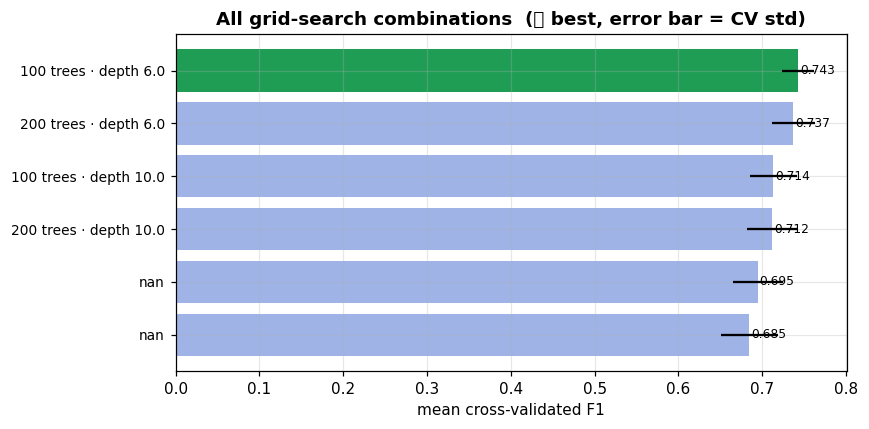

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
results = pd.DataFrame({
    "n_estimators": [p["model__n_estimators"] for p in search.cv_results_["params"]],
    "max_depth": [p["model__max_depth"] for p in search.cv_results_["params"]],
    "mean CV f1": search.cv_results_["mean_test_score"],
    "std": search.cv_results_["std_test_score"],
    "rank": search.cv_results_["rank_test_score"],
}).sort_values("rank").reset_index(drop=True)

display(results.style.hide(axis="index")
        .format({"mean CV f1": "{:.3f}", "std": "{:.3f}"})
        .background_gradient(cmap="Greens", subset=["mean CV f1"]))

labels = results["n_estimators"].astype(str) + " trees · depth " + results["max_depth"].astype(str)
colors = ["#1f9d55" if r == 1 else "#9fb3e6" for r in results["rank"]]
fig, ax = plt.subplots(figsize=(8, 0.5 * len(results) + 1))
ax.barh(range(len(results)), results["mean CV f1"], xerr=results["std"], color=colors)
ax.set_yticks(range(len(results))); ax.set_yticklabels(labels, fontsize=9); ax.invert_yaxis()
for i, v in enumerate(results["mean CV f1"]):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center", fontsize=8)
ax.set_xlabel("mean cross-validated F1")
ax.set_title("All grid-search combinations  (best in green, error bar = CV std)", fontweight="bold")
plt.tight_layout(); plt.show()

## Step 4 — Evaluate: metrics first, then **business cost**

Now that you've searched for better hyperparameters, it's time to answer the key question: **Did the tuning actually improve the model?**

### 4.1 Compare before vs. after hyperparameter tuning

First, let's see the numbers side-by-side. We'll calculate the same metrics we used before:

- **Accuracy** — overall correctness
- **Precision** — of predicted churners, how many actually churned
- **Recall** — of actual churners, how many did we catch?
- **F1-score** — harmonic mean of precision & recall

In [ ]:
# 🎯 TASK — compute the four metrics on the test set (y_test vs predictions).
#    Use accuracy_score, precision_score, recall_score and f1_score.
acc  = None   # 🎯 accuracy_score
prec = None   # 🎯 precision_score
rec  = None   # 🎯 recall_score
f1   = None   # 🎯 f1_score

print(f"accuracy {acc:.3f} · precision {prec:.3f} · recall {rec:.3f} · f1 {f1:.3f}")

accuracy 0.805 · precision 0.740 · recall 0.676 · f1 0.707


**Test** ✅

In [ ]:
for name, v in [("accuracy", acc), ("precision", prec), ("recall", rec), ("f1", f1)]:
    assert 0.0 <= v <= 1.0, f"Hint: {name} should be between 0 and 1."
print("Step 4 (metrics) passed ✅")

Step 4 (metrics) passed ✅


**Visualization** — the confusion matrix: where the model is right and where it confuses stay/churn.

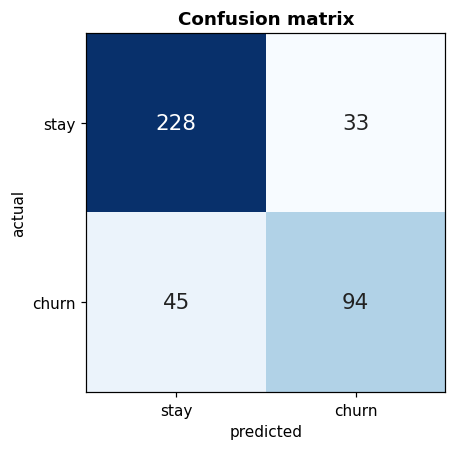

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
cm = confusion_matrix(y_test, predictions)
fig, ax = plt.subplots(figsize=(4.6, 4.2))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["stay", "churn"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["stay", "churn"])
ax.set_xlabel("predicted"); ax.set_ylabel("actual")
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=14,
                color="white" if cm[i, j] > cm.max() / 2 else "#222")
ax.set_title("Confusion matrix", fontweight="bold"); ax.grid(False)
plt.tight_layout(); plt.show()

### Now the part that matters: **business cost**

Accuracy isn't the goal — **minimising money lost** is. Every client falls into one of four cases:

| situation | what happens | cost |
|---|---|---|
| churner, **no** ad | lost client | **100** |
| churner, **ad** | retained — you only pay for the ad | **10** |
| happy client, **no** ad | nothing | **0** |
| happy client, **ad** | annoyed → churns, *and* you paid for the ad | **110** |

**The decision.** We turn each probability into an action with a threshold:
`send_ad = churn_proba >= threshold`. A **high** threshold ads almost no one (cheap on ads, but real
churners slip away); a **low** threshold ads almost everyone (we save churners but annoy happy
clients). The best threshold sits somewhere in between.

**Implementing `business_cost`.** The total is **three buckets**, each a *count of clients × a price*.
Use boolean masks on `send_ad` and `y_true` (`y_true == 1` means the client really churned). `~` flips
a mask and `&` combines two masks element-wise:

- **ad cost** — every ad sent costs `COST_AD` → `COST_AD * send_ad.sum()`
- **missed churners** — churners we did *not* ad, lost at `COST_LOST` each →
  `COST_LOST * ((~send_ad) & (y_true == 1)).sum()`
- **backfired ads** — happy clients we *did* ad (they churn), `COST_LOST` each →
  `COST_LOST * (send_ad & (y_true == 0)).sum()`

**Sweeping the threshold.** There's no formula for the best cut-off, so we simply **try many**: compute
the total cost at each threshold from 0.05 → 0.95, then keep the cheapest one with `np.argmin`. The
plot of cost vs. threshold shows a clear dip — that dip is our policy.

In [ ]:
COST_AD, COST_LOST = 10, 100

def business_cost(y_true, churn_proba, threshold):
    send_ad = churn_proba >= threshold
    # 🎯 TASK — fill in the three cost buckets (see the hints above), then return their sum.
    ad_cost       = None   # 🎯 every ad costs COST_AD                  → COST_AD * send_ad.sum()
    missed_cost   = None   # 🎯 churners with NO ad, COST_LOST each      → ((~send_ad) & (y_true == 1)).sum()
    backfire_cost = None   # 🎯 happy clients WITH an ad, COST_LOST each → (send_ad & (y_true == 0)).sum()
    return ad_cost + missed_cost + backfire_cost

# sweep thresholds and keep the cheapest
y_test_arr = y_test.to_numpy()
thresholds = np.linspace(0.05, 0.95, 19)
costs = [business_cost(y_test_arr, probabilities, t) for t in thresholds]
best_threshold = float(thresholds[int(np.argmin(costs))])

print("best threshold:", round(best_threshold, 2), "· test cost:", min(costs))
print("cost if we ad EVERYONE :", business_cost(y_test_arr, probabilities, 0.0))
print("cost if we ad NO ONE   :", business_cost(y_test_arr, probabilities, 1.01))

best threshold: 0.5 · test cost: 9070
cost if we ad EVERYONE : 30100
cost if we ad NO ONE   : 13900


**Test** ✅

In [ ]:
assert business_cost(y_test_arr, probabilities, 0.0) > min(costs), \
    "Hint: a tuned threshold should beat ad-everyone — check missed_cost / backfire_cost."
print("Step 4 (business) passed ✅  best threshold =", round(best_threshold, 2))

Step 4 (business) passed ✅  best threshold = 0.5


**Visualization** — total business cost across thresholds. The dip is your optimal policy.

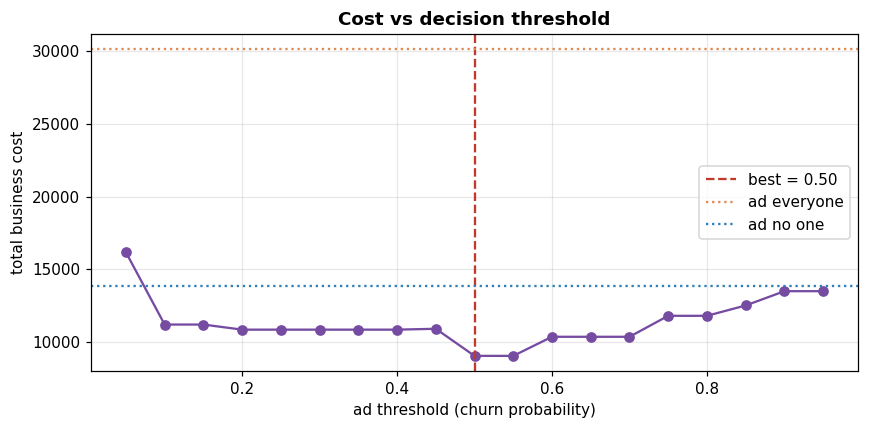

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(thresholds, costs, "-o", color="#764ba2")
ax.axvline(best_threshold, ls="--", color="#c0392b", label=f"best = {best_threshold:.2f}")
ax.axhline(business_cost(y_test_arr, probabilities, 0.0), ls=":", color="#e08a52", label="ad everyone")
ax.axhline(business_cost(y_test_arr, probabilities, 1.01), ls=":", color="#2c7fb8", label="ad no one")
ax.set_xlabel("ad threshold (churn probability)"); ax.set_ylabel("total business cost")
ax.set_title("Cost vs decision threshold", fontweight="bold"); ax.legend()
plt.tight_layout(); plt.show()

## Step 5 — Predict & decide for **this month's** clients

This is the **deployment** moment. Everything so far used *historical* data with known outcomes; now
we apply the finished model to **`current_df`** — real clients whose churn we don't know yet — to
decide who gets a retention ad. Two steps:

1. **Predict** a churn probability for every current client → `model.predict_proba(...)[:, 1]`.
2. **Decide** with the threshold we tuned in Step 4 → `send_ad = current_proba >= best_threshold`.

Since there are **no labels** here, we can't compute the real cost — but we can estimate the
**expected** cost from each probability `p`:

- if we **send an ad**: we pay for it, and *if the client was actually happy* (chance `1 − p`) the ad
  backfires and they churn → `COST_AD + COST_LOST · (1 − p)`
- if we **skip**: *if the client was going to churn* (chance `p`) we lose them → `COST_LOST · p`

Adding up the cost of whichever action we chose, across all clients, gives the **expected business
cost** of our policy — our best guess before the month plays out.

In [ ]:
# the current clients, using the same feature columns the model expects
X_current = current_df[numerical_features + categorical_features].copy()

# 🎯 TASK — churn probabilities for current clients, then the ad decision at best_threshold
current_proba = None     # 🎯 model.predict_proba(X_current)[:, 1]
send_ad       = None     # 🎯 current_proba >= best_threshold

n_ads = int(send_ad.sum())
print(f"clients flagged to churn (proba ≥ {best_threshold:.2f}): {n_ads} of {len(X_current)}")

# expected cost of our policy:  send -> COST_AD + COST_LOST*(1-p) ;  skip -> COST_LOST*p
exp_cost = np.where(send_ad, COST_AD + COST_LOST * (1 - current_proba), COST_LOST * current_proba).sum()
print("expected business cost of the policy:", round(exp_cost))

clients flagged to churn (proba ≥ 0.50): 399 of 1000
expected business cost of the policy: 25849


**Test** ✅

In [ ]:
assert current_proba.shape[0] == len(current_df), "Hint: predict on every current client."
assert current_proba.min() >= 0 and current_proba.max() <= 1, "Hint: use predict_proba(...)[:, 1]."
print("Step 5 passed ✅")

Step 5 passed ✅


## Step 6 — Cluster the likely churners

Knowing *who* will churn isn't enough — we want to know *what kind* of churner they are, so we can
tailor the intervention. The idea of **clustering**: take the flagged clients (who all look like "a
churner") and let an algorithm find natural **groups** that share a behaviour pattern.

C:\Users\sofia\AppData\Local\Temp\ipykernel_49032\796987885.py:19: UserWarning: Glyph 128164 (\N{SLEEPING SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\sofia\AppData\Local\Temp\ipykernel_49032\796987885.py:19: UserWarning: Glyph 128735 (\N{RING BUOY}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\sofia\AppData\Local\Temp\ipykernel_49032\796987885.py:19: UserWarning: Glyph 127793 (\N{SEEDLING}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
C:\Users\sofia\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128164 (\N{SLEEPING SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sofia\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128735 (\N{RING BUOY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\sofia\AppData\Roaming\Python

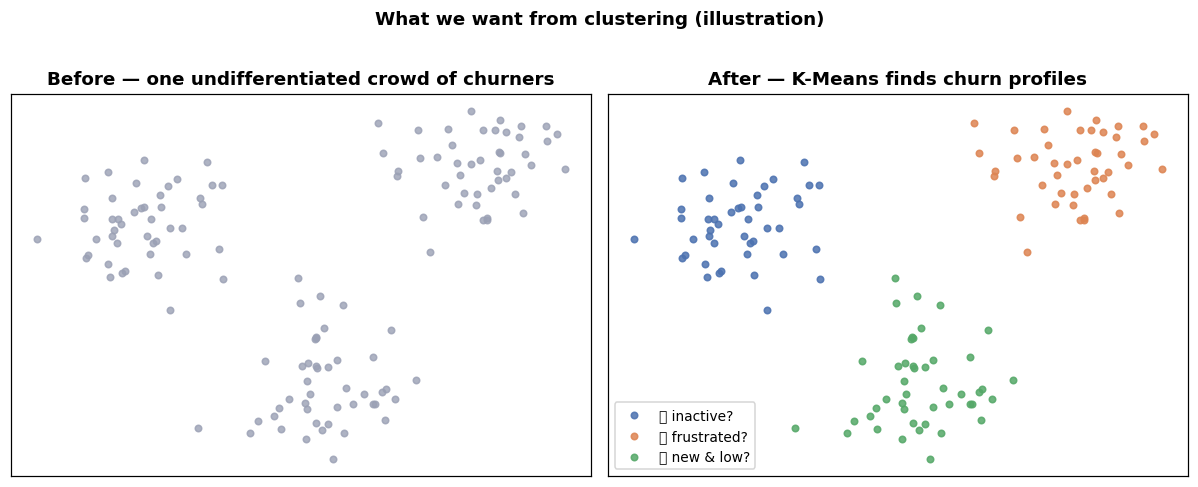

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
rng_demo = np.random.default_rng(0)
centers = [(-2.2, 0.2), (2.0, 1.2), (0.2, -2.2)]
demo = np.vstack([rng_demo.normal(c, 0.55, (45, 2)) for c in centers])
lab = np.repeat([0, 1, 2], 45)
names = ["💤 inactive?", "🛟 frustrated?", "🌱 new & low?"]
cols = ["#4C72B0", "#DD8452", "#55A868"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.scatter(demo[:, 0], demo[:, 1], s=18, color="#9aa0b4", alpha=0.8)
a1.set_title("Before — one undifferentiated crowd of churners", fontweight="bold")
for c in range(3):
    m = lab == c
    a2.scatter(demo[m, 0], demo[m, 1], s=18, color=cols[c], alpha=0.85, label=names[c])
a2.set_title("After — K-Means finds churn profiles", fontweight="bold"); a2.legend(fontsize=9)
for a in (a1, a2):
    a.set_xticks([]); a.set_yticks([]); a.grid(False)
fig.suptitle("What we want from clustering (illustration)", fontweight="bold", y=1.02)
plt.tight_layout(); plt.show()

**How many groups?** K-Means needs us to choose the number of clusters `k` up front — but which
`k`? We run a small **search**: cluster with several values of `k` and score each with the
**silhouette** (how tight and well-separated the clusters are, from −1 to 1 — higher is better) and
the **inertia** (within-cluster spread — always drops as `k` grows, so we look for the "elbow").

> 💡 Fit K-Means only on the **flagged** clients, and on their **behavioural** features. We leave out
> the binary `discount_used` flag, which K-Means (a distance-based method) would over-weight, and
> **standardize** so every feature counts on the same scale.

In [ ]:
likely_churners = current_df[send_ad].copy()

# cluster on the standardized behavioural features (continuous signals of how a client behaves)
cluster_features = ["monthly_usage_hours", "days_since_last_login",
                    "subscription_age_months", "support_tickets"]
cluster_scaler = StandardScaler().fit(likely_churners[cluster_features])
churner_numeric = cluster_scaler.transform(likely_churners[cluster_features])
print("clustering", churner_numeric.shape[0], "likely churners on", churner_numeric.shape[1], "behavioural features")

In [ ]:
# 🎯 TASK — search over the number of clusters and score each one.
candidate_k = [2, 3, 4, 5, 6]
silhouettes, inertias = {}, {}

print(f"{'k':>3} | {'inertia':>9} | {'silhouette':>10}")
for k in candidate_k:
    km = KMeans(n_clusters=k, n_init=10, random_state=0)
    # 🎯 cluster churner_numeric with this km and capture the cluster label per row
    #    (there is a single KMeans method that fits AND returns the labels in one call)
    labels = None    # 🎯 YOUR CODE HERE
    # 🎯 measure how well-separated these clusters are with the silhouette score
    #    (it needs the same data you clustered, plus the labels you just got)
    sil    = None    # 🎯 YOUR CODE HERE
    silhouettes[k], inertias[k] = sil, km.inertia_
    print(f"{k:>3} | {km.inertia_:>9.0f} | {sil:>10.3f}")

best_k = max(silhouettes, key=silhouettes.get)   # k with the highest silhouette
print("→ best k by silhouette:", best_k)

**Visualization** — silhouette (higher = better) and inertia (look for the elbow) across `k`.

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
ks = list(silhouettes.keys())
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.plot(ks, [silhouettes[k] for k in ks], "-o", color="#1f9d55")
a1.axvline(best_k, ls="--", color="#c0392b", label=f"best k = {best_k}")
a1.set_title("Silhouette vs k", fontweight="bold"); a1.set_xlabel("k"); a1.set_ylabel("silhouette"); a1.legend()
a2.plot(ks, [inertias[k] for k in ks], "-o", color="#764ba2")
a2.set_title("Inertia vs k (elbow)", fontweight="bold"); a2.set_xlabel("k"); a2.set_ylabel("inertia")
plt.tight_layout(); plt.show()

Now fit the final K-Means with the chosen `best_k` and label every flagged client:

In [ ]:
kmeans = KMeans(n_clusters=best_k, n_init=10, random_state=0)
clusters = kmeans.fit_predict(churner_numeric)

likely_churners["cluster"] = clusters
print("final cluster sizes (k =", best_k, "):")
print(likely_churners["cluster"].value_counts().sort_index())

**Test** ✅

In [ ]:
assert len(clusters) == len(likely_churners), "Hint: one cluster label per flagged client."
assert len(np.unique(clusters)) == best_k, "Hint: KMeans(n_clusters=best_k) should give best_k groups."
print("Step 6 passed ✅  chose k =", best_k)

## Step 7 — Read the churner profiles

We summarise each cluster by its **average feature values**. The patterns usually map onto
recognisable personas — *inactive* users, *frustrated* heavy users, *weakly-onboarded new* users —
each of which deserves a different intervention.

In [ ]:
profile = likely_churners.groupby("cluster")[numerical_features].mean().round(1)
display(profile)

**Visualization** — cluster sizes, a standardized feature heatmap, and a 2-D PCA map of the groups.

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
means = likely_churners.groupby("cluster")[numerical_features].mean()
z = (means - likely_churners[numerical_features].mean()) / likely_churners[numerical_features].std()

cluster_palette = plt.cm.Set2(np.linspace(0, 1, max(len(np.unique(clusters)), 3)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.4),
                         gridspec_kw={"width_ratios": [1, 1.4]})
sizes = likely_churners["cluster"].value_counts().sort_index()
axes[0].bar(sizes.index.astype(str), sizes.values, color=[cluster_palette[i] for i in range(len(sizes))])
axes[0].set_title("Cluster sizes", fontweight="bold"); axes[0].set_xlabel("cluster")

im = axes[1].imshow(z.to_numpy(), cmap="RdYlGn_r", aspect="auto")
axes[1].set_xticks(range(len(numerical_features)))
axes[1].set_xticklabels(numerical_features, rotation=35, ha="right", fontsize=8)
axes[1].set_yticks(range(len(z))); axes[1].set_yticklabels([f"cluster {i}" for i in z.index])
for i in range(z.shape[0]):
    for j in range(z.shape[1]):
        axes[1].text(j, i, f"{z.to_numpy()[i, j]:+.1f}", ha="center", va="center", fontsize=8, color="#222")
axes[1].set_title("Feature profile per cluster (z-scores: green = low, red = high)", fontweight="bold")
axes[1].grid(False)
plt.tight_layout(); plt.show()

# 2-D PCA scatter
pca = PCA(n_components=2)
xy = pca.fit_transform(churner_numeric)
fig, ax = plt.subplots(figsize=(6.5, 5))
for c in sorted(np.unique(clusters)):
    m = clusters == c
    ax.scatter(xy[m, 0], xy[m, 1], s=18, alpha=0.7, color=cluster_palette[c], label=f"cluster {c}")
ax.set_title("Likely churners in 2-D (PCA)", fontweight="bold")
ax.set_xlabel("PC 1"); ax.set_ylabel("PC 2"); ax.legend()
plt.tight_layout(); plt.show()

## Step 8 — Final answer: strategy & business score

Finally we package everything into a recommendation: how many clients we'd contact, the chosen
threshold, the churner profiles, and a **targeted action** per cluster. We also *reveal* the (hidden)
true outcomes for the current month to see the **realised** cost of our policy versus the naive
strategies — the proof that targeting pays off.

In [ ]:
#@title 📊 Visualization (double-click to view the code) { display-mode: "form" }
# auto-label each cluster from its dominant pattern, then suggest an action
means = likely_churners.groupby("cluster")[numerical_features].mean()
z = (means - likely_churners[numerical_features].mean()) / (likely_churners[numerical_features].std() + 1e-9)
ACTIONS = []
for c in means.index:
    row = z.loc[c]
    if row["support_tickets"] > 0.4 or row["late_payments"] > 0.4:
        label, action, icon = "Frustrated users", "offer a support call / fix", "🛟"
    elif row["subscription_age_months"] < -0.3:
        label, action, icon = "New low-activity users", "send an onboarding tutorial", "🌱"
    else:
        label, action, icon = "Inactive users", "send a reactivation email/offer", "💤"
    ACTIONS.append((c, label, action, icon, int((likely_churners['cluster'] == c).sum())))

# realised cost on the hidden ground truth (normally unavailable!)
def realised(send, truth):
    return COST_AD * send.sum() + COST_LOST * (((~send) & (truth == 1)).sum() + (send & (truth == 0)).sum())
ours = realised(send_ad, current_true_churn)
all_ads = realised(np.ones(len(send_ad), bool), current_true_churn)
no_ads = realised(np.zeros(len(send_ad), bool), current_true_churn)

cards = "".join(
    f'''<div style="flex:1 1 220px;background:#fff;border:1px solid #e6e8ee;border-radius:12px;padding:12px 14px">
        <div style="font-weight:800">{icon} Cluster {c}: {label}</div>
        <div style="font-size:12px;color:#666;margin:4px 0">{n} clients</div>
        <div style="font-size:13px;color:#2c2350">→ <b>{action}</b></div></div>'''
    for c, label, action, icon, n in ACTIONS)

display(HTML(f'''
<div style="font-family:system-ui,Segoe UI,Roboto,sans-serif;background:linear-gradient(135deg,#f5f7ff,#fdf5ff);
     padding:18px;border-radius:18px">
  <h2 style="margin:0 0 10px">📋 Retention strategy</h2>
  <div style="display:flex;gap:14px;flex-wrap:wrap;font-size:14px;margin-bottom:12px">
    <div>🎯 threshold <b>{best_threshold:.2f}</b></div>
    <div>📣 ads sent <b>{int(send_ad.sum())}</b> / {len(send_ad)}</div>
    <div>💸 realised cost <b style="color:#1f9d55">{ours}</b></div>
    <div style="color:#999">vs ad-everyone {all_ads} · ad-no-one {no_ads}</div>
  </div>
  <div style="display:flex;gap:14px;flex-wrap:wrap">{cards}</div>
</div>'''))

fig, ax = plt.subplots(figsize=(6.5, 3.5))
bars = ax.bar(["our policy", "ad everyone", "ad no one"], [ours, all_ads, no_ads],
              color=["#1f9d55", "#c0392b", "#888"])
ax.set_ylabel("realised business cost"); ax.set_title("Did targeting pay off?", fontweight="bold")
for b, v in zip(bars, [ours, all_ads, no_ads]):
    ax.text(b.get_x() + b.get_width() / 2, v, str(int(v)), ha="center", va="bottom", fontsize=10)
plt.tight_layout(); plt.show()

## ✅ What you built

A complete scikit-learn workflow that turns raw customer data into a **business decision**:

**raw data → preprocess → split → fit → predict → evaluate → decide → cluster → targeted actions**

**scikit-learn practiced:** `ColumnTransformer`, `StandardScaler`, `OneHotEncoder`, `Pipeline`,
`train_test_split`, `DecisionTreeClassifier` / `RandomForestClassifier`, `fit` / `predict` /
`predict_proba`, `GridSearchCV` + cross-validation, classification metrics + confusion matrix,
`KMeans`, and `PCA`.

**The one idea to remember:** a model is only as good as the **decision** it supports. Accuracy is a
means; minimising business cost is the end.

### Try it yourself
- Change `COST_AD` / `COST_LOST` — how does the optimal threshold move?
- Try `n_clusters=4`; do new profiles appear?
- Add a feature or tune the grid. Does the realised cost drop?